# **Titan Tutorial**

---

<img align="right" width="300" height="300" src="./images/hail_case_tracks.png">

This interactive tutorial takes you through the steps of how to run the Thunderstorm Identification, Tracking, Analysis and Nowcasting (Titan) application and analyze the output. Titan was originally designed as an algorithm to objectively identify and track thunderstorms from weather radar data for a weather modification experiment in South Africa in the 1980s. Now, Titan includes forecasting, storm analysis, and climatological analysis. Titan now refers to the larger system in which the original application is one component.

Titan is described in more detail in [Dixon and Wiener (1993)](https://doi.org/10.1175/1520-0426(1993)010%3C0785:TTITAA%3E2.0.CO;2).


---

## **Titan Background**

Titan identifies storm objects as a contiguous region of echo that exceeds a user-defined reflectivity threshold and minimum volume. Dual thresholds are used to deal with storm objects that briefly touch, but do not merge. Storm tracking is performed by looking for regions of overlap between storm objects at successive time intervals. Short term storm extrapolation forecasts are used to identify instances of storm merging and splitting. Titan output includes storm tracks, polygons outlining the storm objects, and storm property information (e.g., volume, area, mass, precipitation flux).

The high-level workflow for Titan is shown in the graphic below. Key steps include quality controlling the data to remove any non-meteorological or compromised echoes and gridding the data to a Cartesian grid. Once Titan is run and the tracks are produced, those data need to be converted into more user-friendly file types. 

<img align="center" width="600" src="./images/titan_highlevel.png">

A more detailed workflow for Titan that includes each step, application, and data type is shown in the graphic below.

<img align="center" width="800" src="./images/titan_data_flow.png">

## **Tutorial Overview**
### 1. Setup

#### Pre-processed data and prepare parameter files

Files required to run this notebook:
* Quality controlled radar data between 1600-1700 UTC.

Jastrebac is a 10 cm (S-band) Gematronik dual polarization radar. This hourlong period 

The data from the morning sessions can be found here:

```
  /////
```

### 2. Output data

After the full analysis is run, the following data files should exist:

```
  ./data/titan/storms/20170812.th5 (Titan binary files)
  ./data/titan/ascii/Tracks2Ascii20170812.txt (Titan output converted by Tracks2Ascii)
```

### 3. Note on task cells

This notebook uses two colored cells to indicate tasks.

<div class="alert alert-block alert-info"> <b>File Task: modify parameters in text files.</b> 

These text blocks provide instructions for modifying the parameter files or other functions in *external* text files. These files can be opened through the JupyterHub interface as text files or with your favorite Unix editor (e.g., vi, vim) on a terminal.

</div>

<div class="alert alert-block alert-warning"> <b>Cell Task: run a command in Jupyter notebook cell.</b> 

These text blocks instruct the users to run a command *in* a cell within the Jupyter notebook. If you prefer, you can copy the commands (minus the ! symbol, which is specific to JupyterHub) into a terminal window.

</div>

---

## **1. Setup**
### Environment and packages

First, we import the required python packages to run this notebook. The LROSE processing can be done with the os package and shell commands.

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

### 1.1 Set up directories

We need to set up the required data directories. The raw radar data will be grabbed from the S3 bucket. We delete any existing files and directories specific to this tutorial to ensure we're starting with clean directories and files.

In [ ]:
# make overall titan directory and application output directory
!mkdir -p ./data/titan

# make directory for output ascii files from Titan
!mkdir -p ./data/titan/ascii

### 1.2 Set up the environment

First, we'll set some key variables we'll need throughout the workflow.

In [ ]:
# Set directory variable to call LROSE
os.environ["LROSE_DIR"] = "/usr/local/lrose/bin"

### 1.3 Get data and convert to MDV format

We will use the data that was quality controlled in the earlier part of the data during the ERAD workshop.

Titan requires a specialty format called MDV, which is a form of NetCDF. To determine which application you need, identify whether your quality controlled data are in polar coordinates or have already been gridded to Cartesian files.

If your quality controlled data are in *polar coordinates*, use Radx2Grid to regrid the data to MDV.

<code lang="bash">!$LROSE_DIR/Radx2Grid -params ./params/Radx2Grid.params</code>

In [ ]:
# unzip tar file, hoping to change
!tar -xvf ./data/radar/cfrad/archive.tar.gz -C ./data/radar/cfrad/

# space for commands to find data, if needed
!$LROSE_DIR/Radx2Grid -params ./params/Radx2Grid.params

## **2. Run Titan storm tracking**

To start, we have provided all necessary parameters for you, so you can get a sense for the steps needed to run Titan. We have provided basic parameters including variable names, directories, etc. Once you've completed the first run, you can modify a few parameters and see how the analysis changes (see Section 5).

Run the Titan algorithm to identify and track storms.

Titan runs on the Cartesian gridded data, using the DBZ field and optionally the VEL field to compute storm rotation.

<div class="alert alert-block alert-warning"> <b>Cell Task: Run Titan on derecho case data.</b> 
    <br>
    <br>
    Run the derecho case Titan script:
    <br>
    <br>
    <code lang="bash">!$LROSE_DIR/Titan -params ./params/Titan.params -start "2017 08 12 16 00 00" -end "2017 08 12 17 00 00" -debug</code>
</div>

In [ ]:
# run Titan
!$LROSE_DIR/Titan -params ./params/Titan.params -start "2017 08 12 16 00 00" -end "2017 08 12 17 00 00" -debug

## **3. Convert Titan binary output to readable format**

The Titan output is in a binary format. In order to read the data, we first convert the Titan output to an ASCII file.

<div class="alert alert-block alert-warning"> <b>Cell Task: Convert derecho case Titan output to ASCII.</b> 
    <br>
    <br>
    Run the derecho case ASCII conversion script:
    <br>
    <br>
    <code lang="bash">!$LROSE_DIR/Tracks2Ascii -params ./params/Tracks2Ascii.params -f ./data/titan/storms/20170812.th5 > ./data/titan/ascii/Tracks2Ascii20170812.txt -debug</code>
</div>

In [ ]:
!$LROSE_DIR/Tracks2Ascii -params ./params/Tracks2Ascii.params -f ./data/titan/storms/20170812.th5 > ./data/titan/ascii/Tracks2Ascii20170812.txt -debug

## **4. Investigate Output**

We'll load the necessary Python packages and plot some of the Titan output now.

In [ ]:
# Import Python packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Polygon
from netCDF4 import num2date
import netCDF4 as nc

In [ ]:
file = "./data/titan/ascii/Tracks2Ascii20170812.txt"

### 4.1 Read the ASCII file into a pandas dataframe

Open text file and adjust columns names in order to import to a pandas dataframe. 
Since the text file has irregular delimiters, we need to add some extra steps.

In [ ]:
##open file and extract column names
f = open(file)
lines = f.readlines()
f.close()

label_line_index = None  

for i, line in enumerate(lines):
    if 'labels' in line:
        label_line_index = i
        break  
labels = lines[label_line_index].split(":", 1)[1].strip().split(",")

In [ ]:
#the data lines are the ones that do not start with #
data_lines = [line.strip() for line in lines if not line.startswith("#")]

The file last three rows are labeled "parents", "children", "nPolySidesPolygonRays*72". 

Parents and children columns refer to identifiers based on merging and splitting processes. The Polygon column shows the values for the lines from the polygon centroid to each vertex, in km. There are 72 values because each line is separated 5 deg (72*5 =360). 

With that information and the "envelope_centroid" column, we can retrieve the cells envelopes at each timestep.

In [ ]:
rows = []
for line in data_lines:
    parts = line.split()

    try:
        # Try parsing the polygon count value (always right before 72 values)
        poly_count_index = -73  # 72 floats + 1 count (the column starts with the numnber 72, which is not part of the values)

        # Parents and children may be missing
        parent_str = parts[poly_count_index - 2]
        child_str = parts[poly_count_index - 1]

        # Handle missing values marked as "-"
        parents = int(parent_str) if parent_str != '-' else np.nan
        children = int(child_str) if child_str != '-' else np.nan

        # Polygon values: skip the count, get the next 72 values
        polygon_values = list(map(float, parts[poly_count_index + 1:]))

        # Fixed columns
        fixed_cols = parts[:poly_count_index - 2]

        # Combine into one row
        row = fixed_cols + [parents, children, polygon_values]
        rows.append(row)
    except Exception as e:
        continue

In [ ]:
# Final columns: fixed + 3 custom ones
final_labels = labels[:len(rows[0]) - 3] + ['parents', 'children', 'nPolySidesPolygonRays']

# Create DataFrame
df = pd.DataFrame(rows, columns=final_labels)

# Convert date and time columns to datetime
df['date_utc'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-' +
    df['Day'].astype(str).str.zfill(2) + ' ' + df['Hour'].astype(str).str.zfill(2) + ':' +
    df['Min'].astype(str).str.zfill(2) + ':' + df['Sec'].astype(str).str.zfill(2),
    format='%Y-%m-%d %H:%M:%S', utc=True
)
# Print df 
print(df)

Let's explore the Titan output now!

### 4.2 Examine the number of identified individual storms per complex

#### How does Titan work?

Titan identifies individual radar cells  within every radar volume, based on reflectivity and volume thresholds. Then, it tracks them through time using a combination and optimization scheme, and geometric logic to address splitting and merging storms. In this example, we have set the minimum reflectivity threshold to 35 dBZ. This is shown in column 'dBZThreshold'. That threshold defines the minimum reflectivity for our 'cell' entity.

#### What is the Titan output?

Titan outputs cell fetures at each tracking timestep, and identifies cells within major systems, based on their interaction with neighboring cells. Therefore, each cell will have a simple and a complex identifier (“SimpleNum” and “ComplexNum”) in the Titan output text file. For example, if we are tracking a multicell system, all the individual cells tracked within the major system will have different "SimpleNum" identifiers, however, they will al have the same "ComplexNum" identifier (the main multicell system).

Let's inspect our case now! How many Complexes we can identify? Which one contains more tracks (e.g., single cell tracks, and split/merge processes)?

In [ ]:
# Count number of unique SimpleNum per ComplexNum
simple_counts = df.groupby('ComplexNum')['SimpleNum'].nunique().reset_index(name='NumSimple')

# Sort (optional, for better visuals)
#simple_counts = simple_counts.sort_values(by='NumSimple', ascending=False)

# Plot 1
plt.figure(figsize=(10, 8))
sns.barplot(y='ComplexNum', x='NumSimple', data=simple_counts, palette='Set3')
plt.title('Number of SimpleNum per ComplexNum', fontsize=16)
plt.xlabel('Count of Unique SimpleNum ID', fontsize=14)
plt.ylabel('ComplexNum ID', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.grid(axis='x')
plt.show()


### 4.3 Explore a single complex

Let's now explore more about one of the Complex tracks. In this case, it makes sense to choose **ComplexNum = 17**, which contains more than 25 tracked individual storms.

In our case, we will plot the Maximum Reflectivity (```'MaxDBZ(dBZ)'```) for the entire life cycle of this complex system. Each individual storm is plotted in a different color (see the ```hue='SimpleNum'``` parameter in the plot).

You can play and choose another attribute (e.g., Echo Top, Vil) from the table resulting from Tracks2Ascii, and see how the attributes vary.

In [ ]:
# feel free to modify this variable to see what other complex tracks look like
complexnum = "17"

In [ ]:
#  Filter dataframe for ComplexNum == 0 and sort by time
df0 = df[df['ComplexNum'] == complexnum].copy()
df0 = df0.sort_values('date_utc')
df0['MaxDBZ(dBZ)'] = pd.to_numeric(df0['MaxDBZ(dBZ)'], errors='coerce')
df0['date_utc'] = pd.to_datetime(df0['date_utc'], errors='coerce', utc=True)

#  Plot
y_min = 30
y_max = 70
y_ticks = np.arange(y_min, y_max + 1, 5)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=df0, x='date_utc', y='MaxDBZ(dBZ)', hue='SimpleNum', palette='gist_ncar')
plt.ylim(y_min, y_max)
plt.yticks(y_ticks,fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(fontsize=12)
plt.title('MaxDBZ over Time for ComplexNum = 0', fontsize=16)
plt.xlabel('Time (UTC)', fontsize=14)
plt.ylabel('MaxDBZ (dBZ)',fontsize=14)
# Remove legend
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()


Now we can also plot the centroids of each tracked cell, in a Cartopy map, and add circles around the centroid based on how big the cell volume is in each timestep. We will also show the different cells ('SimpleNum') in different colors.

In [ ]:
df0 = df0.sort_values(['SimpleNum', 'date_utc'])

# Convert lat/lon columns to numeric, coercing errors to NaN
df0['VolCentroidLat(deg)'] = pd.to_numeric(df0['VolCentroidLat(deg)'], errors='coerce')
df0['VolCentroidLon(deg)'] = pd.to_numeric(df0['VolCentroidLon(deg)'], errors='coerce')

# Set up map plot
plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

# Force SimpleNum to categorical (string) for consistent labeling
df0['SimpleNum'] = df0['SimpleNum'].astype(str)

# Unique SimpleNum and colors
simple_nums = df0['SimpleNum'].unique()
palette = sns.color_palette("gist_ncar", n_colors=len(simple_nums))
df0['Volume(km3)'] = pd.to_numeric(df0['Volume(km3)'], errors='coerce').fillna(0)

for i, simple_num in enumerate(simple_nums):
    track = df0[df0['SimpleNum'] == simple_num].copy()
    lat = track['VolCentroidLat(deg)']
    lon = track['VolCentroidLon(deg)']
    vol = pd.to_numeric(track['Volume(km3)'], errors='coerce').fillna(0)
    sizes = np.log10(vol + 1) * 200

    ax.plot(lon, lat, marker='o', linestyle='-', color=palette[i], alpha=0.7,
             label=simple_num, transform=ccrs.PlateCarree())
    ax.scatter(lon, lat, s=sizes, color=palette[i], alpha=0.5,
               transform=ccrs.PlateCarree(), edgecolor='k', linewidth=0.5)

    # Add time labels next to each centroid
    for lo, la, t in zip(lon, lat, track['date_utc']):
        if pd.notna(lo) and pd.notna(la) and pd.notna(t):
            ax.text(lo + 0.02, la + 0.02, t.strftime('%H:%M'),
                    fontsize=8, color=palette[i], transform=ccrs.PlateCarree(),
                    ha='left', va='bottom')

ax.legend(title='SimpleNum', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title('Tracks for ComplexNum = '+complexnum, fontsize=16)
plt.tight_layout()
plt.show()


### 4.4 Examine radar data and storm polygons together

Now let's plot the cartesian radar data at 16:13 UTC and overlap the polygons of the storms that we have identified with Titan.

Plotting field for time: 2017-08-12 16:13:00+00:00
Max reflectivity in column — min/max over field: -1.22 / 68.21
Found 48 polygon(s) matching 2017-08-12 16:13:00+00:00 within radar domain [18.24, 24.65] lon, [41.11, 45.63] lat


/Users/delmoral/miniforge3/envs/pyart_env_n/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/delmoral/miniforge3/envs/pyart_env_n/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


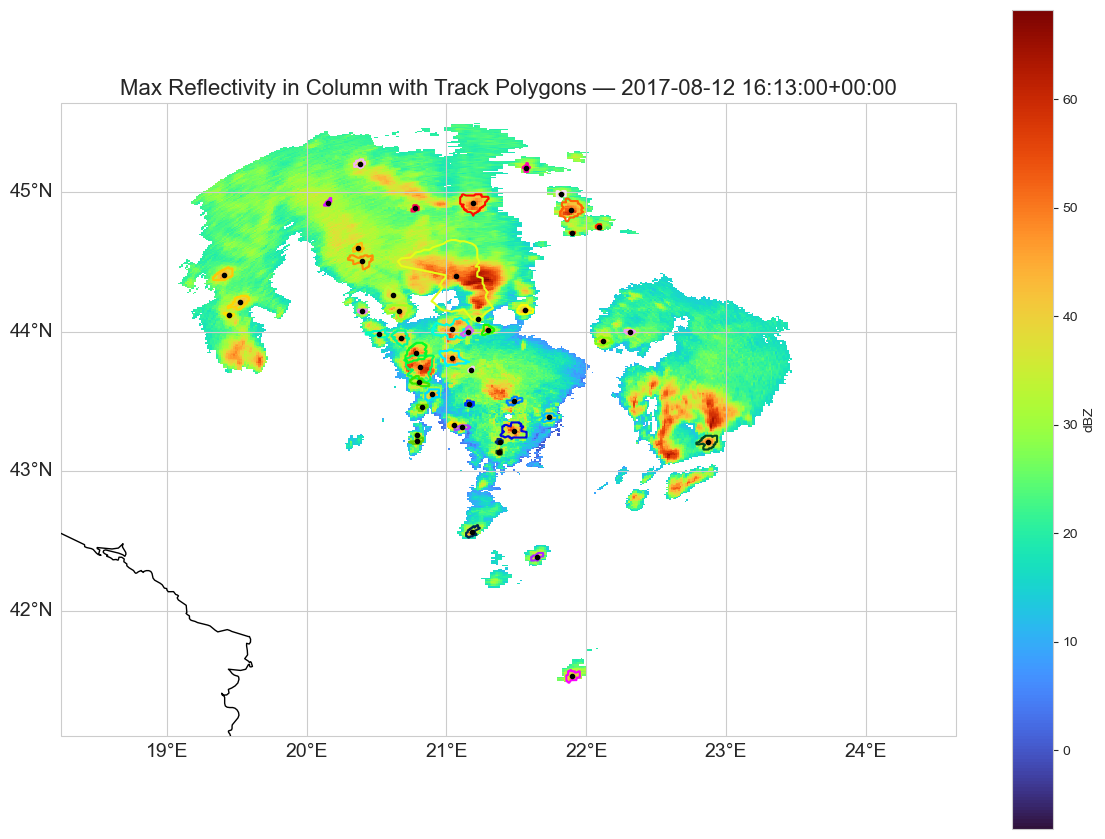

In [ ]:
TIME_IDX = 0

FILEPATH = "./data/cart/20170812/ncf_20170812_161332.nc"   # <-- set your file path here
FIELD_NAME = "DBZ"            

# --- Open, extract everything needed, then close automatically ---
with nc.Dataset(FILEPATH, "r") as ds:
    x = ds.variables["lon0"][:]
    y = ds.variables["lat0"][:]

    var = ds.variables[FIELD_NAME]
    data_3d = var[TIME_IDX, :, :, :]  # all z-levels: shape (z0, y0, x0)

    fill_value = getattr(var, "_FillValue", None)
    if fill_value is not None:
        data_3d = np.ma.masked_equal(data_3d, fill_value)
    data_3d = np.ma.masked_invalid(data_3d)

    # --- Max reflectivity in column: max across the z-axis ---
    data = data_3d.max(axis=0)  # shape (y0, x0)

    # Grab attributes now, while var/ds are still valid
    vmin = getattr(var, "min_value", -10.0)
    vmax = getattr(var, "max_value", 70.0)
    units = getattr(var, "units", FIELD_NAME)

    time_var = ds.variables["time"]
    raw_time = num2date(time_var[TIME_IDX], units=time_var.units,
                         calendar=getattr(time_var, "calendar", "standard"))
    plot_time = pd.Timestamp(raw_time.isoformat())

# --- ds is now closed. Everything below uses only the extracted variables ---

# Handle tz-naive/aware consistently
if plot_time.tz is None:
    plot_time = plot_time.tz_localize("UTC")
else:
    plot_time = plot_time.tz_convert("UTC")

plot_time_min = plot_time.floor("min")
print("Plotting field for time:", plot_time_min)
print(f"Max reflectivity in column — min/max over field: {data.min():.2f} / {data.max():.2f}")

# --- Prep dataframe: correct dtypes ---
df['date_utc'] = pd.to_datetime(df['date_utc'], utc=True)
df['EnvelopeCentroidLon(deg)'] = pd.to_numeric(df['EnvelopeCentroidLon(deg)'], errors='coerce')
df['EnvelopeCentroidLat(deg)'] = pd.to_numeric(df['EnvelopeCentroidLat(deg)'], errors='coerce')

# --- Filter dataframe: match to the minute, within radar domain ---
lon_min, lon_max = float(x.min()), float(x.max())
lat_min, lat_max = float(y.min()), float(y.max())

df_match = df[
    (df['date_utc'].dt.floor("min") == plot_time_min) &
    (df['EnvelopeCentroidLon(deg)'] >= lon_min) &
    (df['EnvelopeCentroidLon(deg)'] <= lon_max) &
    (df['EnvelopeCentroidLat(deg)'] >= lat_min) &
    (df['EnvelopeCentroidLat(deg)'] <= lat_max)
]

print(f"Found {len(df_match)} polygon(s) matching {plot_time_min} within radar domain "
      f"[{lon_min:.2f}, {lon_max:.2f}] lon, [{lat_min:.2f}, {lat_max:.2f}] lat")

if len(df_match) == 0:
    print("WARNING: no polygons match this timestep/domain — check time formats/timezones/extent.")

# --- Build the combined figure ---
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    x, y, data,
    transform=ccrs.PlateCarree(),
    shading="auto", cmap="turbo",
    vmin=vmin, vmax=vmax,
    zorder=1,
)
plt.colorbar(mesh, ax=ax, label=units, shrink=0.7)

ax.coastlines(zorder=3)

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

# --- Overlay only the matching polygons ---
palette = sns.color_palette("gist_ncar", n_colors=max(len(df_match), 1))

for i, (idx, row) in enumerate(df_match.iterrows()):
    lat_centroid = float(row['EnvelopeCentroidLat(deg)'])
    lon_centroid = float(row['EnvelopeCentroidLon(deg)'])
    rays = row['nPolySidesPolygonRays']

    if not rays or len(rays) == 0:
        continue

    angles = np.deg2rad(np.arange(0, 360, 5))
    rays = np.array(rays, dtype=float)

    ray_x = rays * np.cos(angles)
    ray_y = rays * np.sin(angles)
    lat_vertices = lat_centroid + ray_y / 111
    lon_vertices = lon_centroid + ray_x / (111 * np.cos(np.deg2rad(lat_centroid)))
    polygon_points = list(zip(lon_vertices, lat_vertices))

    poly = Polygon(polygon_points)
    ax.add_geometries([poly], crs=ccrs.PlateCarree(),
                       edgecolor=palette[i], facecolor='none', linewidth=1.5,
                       zorder=4)

    ax.plot(lon_centroid, lat_centroid, marker='o', color='black', markersize=3,
             transform=ccrs.PlateCarree(), zorder=5)

plt.title(f"Max Reflectivity in Column with Track Polygons — {plot_time_min}", fontsize=16)
plt.tight_layout()
plt.show()

## **5. Explore how the storm track analysis is impacted by key parameters**

Now that you've successfully run Titan, we invite you to explore how parameter selection affects the final analysis. Here, we'll focus on three parameters.

We strongly recommend creating new parameter files and output directories so that you retain all examples from today.

To create a new parameter file with existing parameters, run a variation of the following command, updating the output file name at the end.

<code lang="bash">!$LROSE_DIR/Titan -params ./params/Titan.params -print_params > ./params/Titan.params.new</code>

### 2.1 Reflectivity threshold

A key parameter for Titan is the minimum reflectivity value considered for storm identification: low_dbz_threshold. Storms are defined as regions with reflectivity values in excess of this value.

The default value in Titan is 35 dBZ, but this may need to change based on the air mass, storm type, etc. 

Values to consider testing: 
* 30 dBZ
* 40 dBZ
* 45 dBZ

A reminder to update the output directory for the Titan binary files and the ASCII files, as shown in an example below (note the three instances of the "_30" suffix, but feel free to rename as you prefer).

<code lang="bash">!$LROSE_DIR/Titan -params ./params/Titan.params.new -odir ./data/titan/storms_30 -start "2017 08 12 16 00 00" -end "2017 08 12 17 00 00" -debug</code>

<code lang="bash">!$LROSE_DIR/Tracks2Ascii -params ./params/Tracks2Ascii.params -f ./data/titan/storms_30/20170812.th5 > ./data/titan/ascii_30/Tracks2Ascii20170812.txt -debug</code>

When you copy the plotting code from above, you'll need to update the file paths. Based on the complex numbers, you'll also need to pick a different complexnum.

```python
file = "./data/titan/ascii_30/Tracks2Ascii20170812.txt"
complexnum = "17" # change to the appropriate number
```

### 2.2 Extension

### 2.3 Tracking variable

Titan offers two options for the storm tracking variable: 1) the 3-D reflectivity field (default) and 2) the column maximum reflectivity. This option is set in the variable use_column_max_dbz, where FALSE (default) tracks the 3-D reflectivity field and TRUE tracks the column maximum reflectivity.

Note, if use_column_max_dbz = TRUE, then the user must set the height range over which the maximum reflectivity is calulated using the following parameters: column_min_ht_km and column_max_ht_km.

Consider testing: 
* use_column_max_dbz = TRUE

A reminder to update the output directory for the Titan binary files and the ASCII files, as shown in an example below (note the three instances of the "_column" suffix, but feel free to rename as you prefer).

<code lang="bash">!$LROSE_DIR/Titan -params ./params/Titan.params.new -odir ./data/titan/storms_column -start "2017 08 12 16 00 00" -end "2017 08 12 17 00 00" -debug</code>

<code lang="bash">!$LROSE_DIR/Tracks2Ascii -params ./params/Tracks2Ascii.params -f ./data/titan/storms_column/20170812.th5 > ./data/titan/ascii_column/Tracks2Ascii20170812.txt -debug</code>

When you copy the plotting code from above, you'll need to update the file paths. Based on the complex numbers, you'll also need to pick a different complexnum.

```python
file = "./data/titan/ascii_suffix/Tracks2Ascii20170812.txt"
complexnum = "17" # change to the appropriate number
```